In [9]:
#!/usr/bin/env python3
from __future__ import annotations

import argparse
import json
import sys
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import torch
from scipy.stats import pearsonr, spearmanr

EPS = 1e-12
DEFAULT_SCDIFFUSION_PATH = "/home/suzuki/Projects/scDiffusion"
DEFAULT_ADATA_PATH = "/home/suzuki/Projects/scDiffusion/work/20260215_embryonic/data/Embryonic.h5ad"
DEFAULT_MODEL_PATH1 = "/home/suzuki/Projects/scDiffusion/work/20260215_embryonic/20260224_084326_Lamda5/20260224_084328_train/checkpoints/pbmc68k_soft_20251127_hvg1024/ema_0.9999_100000.pt"
DEFAULT_MODEL_PATH2 = "/home/suzuki/Projects/scDiffusion/work/20260215_embryonic/20260224_084326_Lamda5/20260224_084328_train/checkpoints/pbmc68k_soft_20251127_hvg1024/ema_0.9999_000000.pt"
DEFAULT_EDGE_TSV_PATH = "/home/suzuki/Projects/scDiffusion/external_data/Mouse_tf_target_edges.tsv"
DEFAULT_TARGET_SUPERCLASS = "Erythropoietic"
DEFAULT_TIMESTEPS = 1000
DEFAULT_BATCH_SIZE = 1024


@dataclass
class RunAssets:
    gene_names: list[str]
    X: np.ndarray
    obs_names: np.ndarray | None
    adata_path: str
    model_path1: str
    model_path2: str
    edge_tsv_path: str
    target_superclass: str | None


# -----------------------------------------------------------------------------
# basic utilities
# -----------------------------------------------------------------------------
def setup_environment(scdiffusion_path: str) -> None:
    if scdiffusion_path not in sys.path:
        sys.path.insert(0, scdiffusion_path)


def make_output_dir(prefix: str) -> Path:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    outdir = Path.cwd() / f"{timestamp}_{prefix}"
    outdir.mkdir(parents=True, exist_ok=True)
    print(f"[INFO] Output directory: {outdir}")
    return outdir


def ensure_dense_float32(X: Any) -> np.ndarray:
    if sp.issparse(X):
        X = X.toarray()
    X = np.asarray(X, dtype=np.float32)
    X[~np.isfinite(X)] = 0.0
    return X


def safe_pearson(x: np.ndarray, y: np.ndarray) -> float:
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if x.size < 3:
        return np.nan
    if np.std(x) < EPS or np.std(y) < EPS:
        return np.nan
    return float(pearsonr(x, y)[0])


def safe_spearman(x: np.ndarray, y: np.ndarray) -> float:
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if x.size < 3:
        return np.nan
    if np.std(x) < EPS or np.std(y) < EPS:
        return np.nan
    return float(spearmanr(x, y)[0])


def safe_linear_fit(x: np.ndarray, y: np.ndarray) -> tuple[float, float]:
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if x.size < 2:
        return np.nan, np.nan
    if np.std(x) < EPS:
        return np.nan, np.nan
    a, b = np.polyfit(x, y, deg=1)
    return float(a), float(b)


def finite_var(arr: np.ndarray) -> float:
    vals = arr[np.isfinite(arr)]
    if vals.size == 0:
        return np.nan
    return float(np.var(vals))


# -----------------------------------------------------------------------------
# checkpoint / model helpers
# -----------------------------------------------------------------------------
def checkpoint_to_state_dict(checkpoint: Any) -> dict[str, Any]:
    if isinstance(checkpoint, dict):
        return checkpoint.get("model_state_dict", checkpoint.get("model", checkpoint))
    return checkpoint


def load_model(
    model_path: str,
    gene_list: list[str],
    edge_tsv_path: str,
    device: torch.device,
    timesteps: int,
):
    from guided_diffusion.cell_model import Cell_Unet
    from ODE.ode_analysis1106 import GeneODE, ODE_ML_Hybrid

    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    state_dict = checkpoint_to_state_dict(checkpoint)

    ode = GeneODE(
        gene_list=gene_list,
        edge_tsv_path=edge_tsv_path,
        soft=True,
        device=device,
    )
    ml_model = Cell_Unet(input_dim=len(gene_list))
    hybrid_model = ODE_ML_Hybrid(
        ode_model=ode,
        ml_model=ml_model,
        timesteps=timesteps,
    ).to(device)

    hybrid_model.load_state_dict(state_dict, strict=False)
    hybrid_model.eval()
    return hybrid_model


def compute_velocity_matrix(
    hybrid_model,
    X: np.ndarray,
    device: torch.device,
    batch_size: int,
) -> np.ndarray:
    n = X.shape[0]
    V = np.zeros_like(X, dtype=np.float32)

    with torch.no_grad():
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            xb = torch.from_numpy(X[start:end]).to(device)
            vb = hybrid_model.ode_model(xb).detach().cpu().numpy()
            V[start:end] = np.asarray(vb, dtype=np.float32)

    V[~np.isfinite(V)] = 0.0
    return V


def compute_alpha_and_velocity_batch(
    ode_model,
    xb: torch.Tensor,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    xb = xb.float()
    W_eff = ode_model.W if ode_model.soft else (ode_model.W * ode_model.mask)
    Wx = xb @ W_eff + ode_model.b
    alpha = torch.sigmoid(Wx * ode_model.scale)
    velocity = alpha - ode_model.gamma * xb
    return (
        alpha.detach().cpu().numpy().astype(np.float64, copy=False),
        velocity.detach().cpu().numpy().astype(np.float64, copy=False),
        xb.detach().cpu().numpy().astype(np.float64, copy=False),
    )


def accumulate_ode_diagnostics(
    hybrid_model,
    X: np.ndarray,
    device: torch.device,
    batch_size: int,
) -> pd.DataFrame:
    n_cells, n_genes = X.shape
    ode = hybrid_model.ode_model
    gamma = ode.gamma.detach().cpu().numpy().astype(np.float64)

    sum_alpha = np.zeros(n_genes, dtype=np.float64)
    sum_alpha_sq = np.zeros(n_genes, dtype=np.float64)
    sum_abs_alpha = np.zeros(n_genes, dtype=np.float64)
    sum_abs_gamma_x = np.zeros(n_genes, dtype=np.float64)
    frac_alpha_low = np.zeros(n_genes, dtype=np.float64)
    frac_alpha_high = np.zeros(n_genes, dtype=np.float64)

    with torch.no_grad():
        for start in range(0, n_cells, batch_size):
            end = min(start + batch_size, n_cells)
            xb = torch.from_numpy(X[start:end]).to(device)
            alpha, _, x_np = compute_alpha_and_velocity_batch(ode, xb)

            sum_alpha += alpha.sum(axis=0)
            sum_alpha_sq += (alpha ** 2).sum(axis=0)
            sum_abs_alpha += np.abs(alpha).sum(axis=0)
            sum_abs_gamma_x += np.abs(gamma[None, :] * x_np).sum(axis=0)
            frac_alpha_low += (alpha < 0.05).sum(axis=0)
            frac_alpha_high += (alpha > 0.95).sum(axis=0)

    mean_alpha = sum_alpha / max(n_cells, 1)
    var_alpha = np.maximum(sum_alpha_sq / max(n_cells, 1) - mean_alpha**2, 0.0)
    std_alpha = np.sqrt(var_alpha)

    df = pd.DataFrame(
        {
            "gamma": gamma,
            "mean_alpha": mean_alpha,
            "var_alpha": var_alpha,
            "std_alpha": std_alpha,
            "mean_abs_alpha": sum_abs_alpha / max(n_cells, 1),
            "mean_abs_gamma_x": sum_abs_gamma_x / max(n_cells, 1),
            "gamma_term_over_alpha": (sum_abs_gamma_x / max(n_cells, 1))
            / ((sum_abs_alpha / max(n_cells, 1)) + EPS),
            "frac_alpha_lt_005": frac_alpha_low / max(n_cells, 1),
            "frac_alpha_gt_095": frac_alpha_high / max(n_cells, 1),
        }
    )
    return df


# -----------------------------------------------------------------------------
# data loading
# -----------------------------------------------------------------------------
def load_assets(args: argparse.Namespace) -> RunAssets:
    print(f"[INFO] Loading adata: {args.adata_path}")
    adata = sc.read_h5ad(args.adata_path)
    adata_path_used = args.adata_path
    target_superclass = args.target_superclass

    if target_superclass:
        if "Superclass" not in adata.obs.columns:
            raise KeyError("'Superclass' column not found in adata.obs")
        adata = adata[adata.obs["Superclass"] == target_superclass].copy()
        if adata.n_obs == 0:
            raise ValueError(f"No cells found for Superclass == {target_superclass}")
        print(f"[INFO] Subset: {target_superclass}, n_obs={adata.n_obs}, n_vars={adata.n_vars}")

    X = ensure_dense_float32(adata.X)
    gene_names = list(adata.var_names.astype(str))
    obs_names = np.asarray(adata.obs_names.astype(str))

    return RunAssets(
        gene_names=gene_names,
        X=X,
        obs_names=obs_names,
        adata_path=adata_path_used,
        model_path1=args.model_path1,
        model_path2=args.model_path2,
        edge_tsv_path=args.edge_tsv_path,
        target_superclass=target_superclass,
    )


# -----------------------------------------------------------------------------
# analysis
# -----------------------------------------------------------------------------
def compute_gene_metrics(
    gene_names: list[str],
    V1: np.ndarray,
    V2: np.ndarray,
) -> pd.DataFrame:
    rows = []

    for j, gene in enumerate(gene_names):
        v1 = np.asarray(V1[:, j], dtype=np.float64)
        v2 = np.asarray(V2[:, j], dtype=np.float64)

        valid_mask = np.isfinite(v1) & np.isfinite(v2)
        vv1 = v1[valid_mask]
        vv2 = v2[valid_mask]
        n_valid = int(valid_mask.sum())

        pearson_r = safe_pearson(vv1, vv2)
        spearman_r = safe_spearman(vv1, vv2)
        slope, intercept = safe_linear_fit(vv1, vv2)

        rows.append(
            {
                "gene": gene,
                "n_valid_cells": n_valid,
                "pearson_r": pearson_r,
                "spearman_r": spearman_r,
                "slope_v2_on_v1": slope,
                "intercept_v2_on_v1": intercept,
                "mean_v1": float(np.mean(vv1)) if n_valid > 0 else np.nan,
                "mean_v2": float(np.mean(vv2)) if n_valid > 0 else np.nan,
                "std_v1": float(np.std(vv1)) if n_valid > 0 else np.nan,
                "std_v2": float(np.std(vv2)) if n_valid > 0 else np.nan,
                "mean_abs_v1": float(np.mean(np.abs(vv1))) if n_valid > 0 else np.nan,
                "mean_abs_v2": float(np.mean(np.abs(vv2))) if n_valid > 0 else np.nan,
            }
        )

    return pd.DataFrame(rows)


def merge_metrics(
    gene_metrics: pd.DataFrame,
    diag1: pd.DataFrame,
    diag2: pd.DataFrame,
) -> pd.DataFrame:
    diag1 = diag1.add_prefix("m1_")
    diag2 = diag2.add_prefix("m2_")

    df = pd.concat(
        [
            gene_metrics.reset_index(drop=True),
            diag1.reset_index(drop=True),
            diag2.reset_index(drop=True),
        ],
        axis=1,
    )

    g1 = df["m1_gamma"].to_numpy(dtype=np.float64)
    g2 = df["m2_gamma"].to_numpy(dtype=np.float64)
    slope = df["slope_v2_on_v1"].to_numpy(dtype=np.float64)

    gamma_ratio = np.full_like(g1, np.nan, dtype=np.float64)
    valid_ratio = np.isfinite(g1) & np.isfinite(g2) & (np.abs(g1) > EPS)
    gamma_ratio[valid_ratio] = g2[valid_ratio] / g1[valid_ratio]

    df["gamma_ratio_g2_over_g1"] = gamma_ratio
    df["delta_slope_minus_gamma_ratio"] = slope - gamma_ratio
    df["abs_delta_slope_minus_gamma_ratio"] = np.abs(df["delta_slope_minus_gamma_ratio"])
    df["sign_match_slope_gamma_ratio"] = np.sign(df["slope_v2_on_v1"]) == np.sign(
        df["gamma_ratio_g2_over_g1"]
    )
    df["alpha_saturation_score_m1"] = np.maximum(
        df["m1_frac_alpha_lt_005"], df["m1_frac_alpha_gt_095"]
    )
    df["alpha_saturation_score_m2"] = np.maximum(
        df["m2_frac_alpha_lt_005"], df["m2_frac_alpha_gt_095"]
    )
    df["gamma_dominance_mean"] = 0.5 * (
        df["m1_gamma_term_over_alpha"] + df["m2_gamma_term_over_alpha"]
    )
    return df


# -----------------------------------------------------------------------------
# plots (display only, no save)
# -----------------------------------------------------------------------------
def _finite_xy(
    df: pd.DataFrame,
    xcol: str,
    ycol: str,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    x = df[xcol].to_numpy(dtype=np.float64)
    y = df[ycol].to_numpy(dtype=np.float64)
    mask = np.isfinite(x) & np.isfinite(y)
    return x[mask], y[mask], mask


def plot_slope_vs_gamma_ratio(df: pd.DataFrame) -> None:
    x, y, _ = _finite_xy(df, "gamma_ratio_g2_over_g1", "slope_v2_on_v1")

    plt.figure(figsize=(8, 8))
    if x.size > 0:
        plt.scatter(x, y, s=18, alpha=0.65)
        corr = safe_pearson(x, y)

        lo = np.nanpercentile(np.concatenate([x, y]), 1)
        hi = np.nanpercentile(np.concatenate([x, y]), 99)
        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            lo = min(np.nanmin(x), np.nanmin(y))
            hi = max(np.nanmax(x), np.nanmax(y))

        pad = 0.05 * max(hi - lo, 1e-6)
        lo, hi = lo - pad, hi + pad

        plt.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.5, label="y = x")
        plt.xlim(lo, hi)
        plt.ylim(lo, hi)
        plt.legend(loc="best")
        plt.title(
            f"Slope vs gamma2/gamma1\nN={x.size}, Pearson={corr:.4f}"
            if np.isfinite(corr)
            else f"Slope vs gamma2/gamma1\nN={x.size}"
        )
    else:
        plt.text(0.5, 0.5, "No finite points", ha="center", va="center")
        plt.title("Slope vs gamma2/gamma1")

    plt.xlabel("gamma2 / gamma1")
    plt.ylabel("slope of regression V2 ~ a * V1 + b")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()
    plt.close()


def plot_delta_hist(df: pd.DataFrame) -> dict[str, float]:
    delta = df["delta_slope_minus_gamma_ratio"].to_numpy(dtype=np.float64)
    delta = delta[np.isfinite(delta)]

    mean = float(np.mean(delta)) if delta.size else np.nan
    var = finite_var(delta)
    median = float(np.median(delta)) if delta.size else np.nan

    plt.figure(figsize=(9, 6))
    if delta.size > 0:
        plt.hist(delta, bins=60, alpha=0.75)
        plt.axvline(0.0, linestyle="--", linewidth=1.5)
        plt.title("Histogram of slope - gamma2/gamma1")
        caption = f"mean={mean:.6g}   var={var:.6g}   median={median:.6g}   N={delta.size}"
        plt.figtext(0.5, 0.01, caption, ha="center", fontsize=10)
    else:
        plt.text(0.5, 0.5, "No finite delta values", ha="center", va="center")
        plt.title("Histogram of slope - gamma2/gamma1")

    plt.xlabel("slope - gamma2/gamma1")
    plt.ylabel("gene count")
    plt.grid(True, alpha=0.25)
    plt.tight_layout(rect=(0, 0.04, 1, 1))
    plt.show()
    plt.close()

    return {"mean": mean, "var": var, "median": median, "n": int(delta.size)}


def plot_gamma_dominance_vs_abs_delta(df: pd.DataFrame) -> None:
    x, y, _ = _finite_xy(df, "gamma_dominance_mean", "abs_delta_slope_minus_gamma_ratio")

    plt.figure(figsize=(8, 6))
    if x.size > 0:
        plt.scatter(x, y, s=18, alpha=0.6)
        corr = safe_pearson(x, y)
        title = f"Gamma dominance vs |slope - gamma_ratio|\nN={x.size}"
        if np.isfinite(corr):
            title += f", Pearson={corr:.4f}"
        plt.title(title)
    else:
        plt.text(0.5, 0.5, "No finite points", ha="center", va="center")
        plt.title("Gamma dominance vs |slope - gamma_ratio|")

    plt.xlabel("0.5 * [(|gamma*x|/|alpha|)_m1 + (|gamma*x|/|alpha|)_m2]")
    plt.ylabel("|slope - gamma2/gamma1|")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()
    plt.close()

def _common_bins(x1: np.ndarray, x2: np.ndarray, bins: int = 60) -> np.ndarray:
    x1 = x1[np.isfinite(x1)]
    x2 = x2[np.isfinite(x2)]
    all_x = np.concatenate([x1, x2]) if (x1.size + x2.size) > 0 else np.array([0.0, 1.0])

    if all_x.size == 0:
        return np.linspace(0.0, 1.0, bins + 1)

    xmin = np.min(all_x)
    xmax = np.max(all_x)

    if not np.isfinite(xmin) or not np.isfinite(xmax) or xmin == xmax:
        xmin = xmin - 0.5 if np.isfinite(xmin) else 0.0
        xmax = xmax + 0.5 if np.isfinite(xmax) else 1.0

    return np.linspace(xmin, xmax, bins + 1)


def plot_alpha_mean_hist(diag1: pd.DataFrame, diag2: pd.DataFrame, bins: int = 60) -> None:
    a1 = diag1["mean_alpha"].to_numpy(dtype=np.float64)
    a2 = diag2["mean_alpha"].to_numpy(dtype=np.float64)
    a1 = a1[np.isfinite(a1)]
    a2 = a2[np.isfinite(a2)]

    edges = _common_bins(a1, a2, bins=bins)

    plt.figure(figsize=(9, 6))
    plt.hist(a1, bins=edges, alpha=0.4, label=f"model1 mean_alpha (n={a1.size})")
    plt.hist(a2, bins=edges, alpha=0.4, label=f"model2 mean_alpha (n={a2.size})")

    plt.title("Histogram of gene-wise mean(alpha)")
    plt.xlabel("mean(alpha)")
    plt.ylabel("gene count")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.close()


def plot_alpha_var_hist(diag1: pd.DataFrame, diag2: pd.DataFrame, bins: int = 60) -> None:
    v1 = diag1["var_alpha"].to_numpy(dtype=np.float64)
    v2 = diag2["var_alpha"].to_numpy(dtype=np.float64)
    v1 = v1[np.isfinite(v1)]
    v2 = v2[np.isfinite(v2)]

    edges = _common_bins(v1, v2, bins=bins)

    plt.figure(figsize=(9, 6))
    plt.hist(v1, bins=edges, histtype="step", linewidth=2, label=f"model1 var_alpha (n={v1.size})")
    plt.hist(v2, bins=edges, histtype="step", linewidth=2, label=f"model2 var_alpha (n={v2.size})")

    plt.title("Histogram of gene-wise var(alpha)")
    plt.xlabel("var(alpha)")
    plt.ylabel("gene count")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.close()

# -----------------------------------------------------------------------------
# reports
# -----------------------------------------------------------------------------
def write_summary(
    df: pd.DataFrame,
    delta_stats: dict[str, float],
    outpath: Path,
    args: argparse.Namespace,
    assets: RunAssets,
) -> None:
    finite_mask = np.isfinite(df["gamma_ratio_g2_over_g1"].to_numpy(dtype=np.float64)) & np.isfinite(
        df["slope_v2_on_v1"].to_numpy(dtype=np.float64)
    )
    x = df.loc[finite_mask, "gamma_ratio_g2_over_g1"].to_numpy(dtype=np.float64)
    y = df.loc[finite_mask, "slope_v2_on_v1"].to_numpy(dtype=np.float64)

    summary = {
        "n_genes_total": int(df.shape[0]),
        "n_genes_finite_slope_and_gamma_ratio": int(finite_mask.sum()),
        "pearson_slope_vs_gamma_ratio": safe_pearson(x, y),
        "spearman_slope_vs_gamma_ratio": safe_spearman(x, y),
        "delta_mean": delta_stats["mean"],
        "delta_variance": delta_stats["var"],
        "delta_median": delta_stats["median"],
        "top10_most_negative_pearson_genes": df.sort_values("pearson_r", ascending=True).head(10)["gene"].tolist(),
        "top10_smallest_abs_delta_genes": df.sort_values("abs_delta_slope_minus_gamma_ratio", ascending=True).head(10)["gene"].tolist(),
        "top10_largest_gamma_dominance_genes": df.sort_values("gamma_dominance_mean", ascending=False).head(10)["gene"].tolist(),
        "config": {
            "adata_path": assets.adata_path,
            "model_path1": assets.model_path1,
            "model_path2": assets.model_path2,
            "edge_tsv_path": assets.edge_tsv_path,
            "target_superclass": assets.target_superclass,
            "batch_size": args.batch_size,
            "timesteps": args.timesteps,
            "device": args.device,
            "save_velocities": args.save_velocities,
            "tag": args.tag,
        },
    }

    with open(outpath, "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)


def write_readme(outdir: Path) -> None:
    text = """This directory contains a gene-wise comparison between
1) slope of the regression V2 ~ a * V1 + b
2) gamma2 / gamma1 extracted from the ODE checkpoints

Files:
- gene_level_gamma_slope_metrics.csv : main table
- gene_level_gamma_slope_metrics.parquet : optional parquet table
- summary.json                      : compact numeric summary
- run_args.json                     : execution record

Interpretation tip:
If out ≈ c - gamma * x gene-wise, then slope(V1->V2) should be close to gamma2/gamma1.
If alpha is saturated and/or gamma*x dominates alpha, this approximation tends to hold better.

Plots are not saved by this script.
They are displayed inline / on screen only via matplotlib.
"""
    with open(outdir / "README.txt", "w", encoding="utf-8") as f:
        f.write(text)


def write_run_record(outdir: Path, args: argparse.Namespace) -> None:
    run_record = {
        "timestamp": datetime.now().isoformat(),
        "cwd": str(Path.cwd()),
        "command": " ".join(sys.argv),
        "argv": sys.argv,
        "args": vars(args),
    }
    with open(outdir / "run_args.json", "w", encoding="utf-8") as f:
        json.dump(run_record, f, ensure_ascii=False, indent=2)


# -----------------------------------------------------------------------------
# main
# -----------------------------------------------------------------------------
def parse_args(argv=None) -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Compare slope(V1,V2) with gamma2/gamma1 in the ODE velocity model."
    )
    parser.add_argument("--scdiffusion-path", default=DEFAULT_SCDIFFUSION_PATH)
    parser.add_argument("--adata-path", default=DEFAULT_ADATA_PATH)
    parser.add_argument("--model-path1", default=DEFAULT_MODEL_PATH1)
    parser.add_argument("--model-path2", default=DEFAULT_MODEL_PATH2)
    parser.add_argument("--edge-tsv-path", default=DEFAULT_EDGE_TSV_PATH)
    parser.add_argument("--target-superclass", default=DEFAULT_TARGET_SUPERCLASS)
    parser.add_argument("--batch-size", type=int, default=DEFAULT_BATCH_SIZE)
    parser.add_argument("--timesteps", type=int, default=DEFAULT_TIMESTEPS)
    parser.add_argument("--device", default=None, help="cpu / cuda. default: auto")
    parser.add_argument("--save-velocities", action="store_true", help="Save computed velocities into the output dir.")
    parser.add_argument("--tag", default="", help="Short memo for this run.")
    return parser.parse_args(argv)


In [3]:
args = argparse.Namespace(
    scdiffusion_path="/home/suzuki/Projects/scDiffusion",
    adata_path="/home/suzuki/Projects/scDiffusion/work/20260215_embryonic/data/Embryonic.h5ad",
    model_path1="/home/suzuki/Projects/scDiffusion/work/20260215_embryonic/20260224_084326_Lamda5/20260224_084328_train/checkpoints/pbmc68k_soft_20251127_hvg1024/ema_0.9999_100000.pt",
    model_path2="/home/suzuki/Projects/scDiffusion/work/20260215_embryonic/20260224_084326_Lamda5/20260224_084328_train/checkpoints/pbmc68k_soft_20251127_hvg1024/ema_0.9999_000000.pt",
    edge_tsv_path="/home/suzuki/Projects/scDiffusion/external_data/Mouse_tf_target_edges.tsv",
    target_superclass="Erythropoietic",
    batch_size=1024,
    timesteps=1000,
    device=None,
    save_velocities=False,
    tag="gamma_vs_slope_check",
)


In [10]:
if args is None:
    args = parse_args()

setup_environment(args.scdiffusion_path)
outdir = make_output_dir("gamma_slope_velocity_analysis")

device = torch.device(args.device if args.device else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"[INFO] Device: {device}")

assets = load_assets(args)

model1 = load_model(
    assets.model_path1,
    assets.gene_names,
    assets.edge_tsv_path,
    device,
    args.timesteps,
)
model2 = load_model(
    assets.model_path2,
    assets.gene_names,
    assets.edge_tsv_path,
    device,
    args.timesteps,
)

print("[INFO] Computing V1 from model_path1 ...")
V1 = compute_velocity_matrix(model1, assets.X, device, args.batch_size)

print("[INFO] Computing V2 from model_path2 ...")
V2 = compute_velocity_matrix(model2, assets.X, device, args.batch_size)

if args.save_velocities:
    np.savez_compressed(
        outdir / "velocities_computed.npz",
        V1=V1.astype(np.float32),
        V2=V2.astype(np.float32),
        var_names=np.asarray(assets.gene_names, dtype=object),
        obs_names=assets.obs_names if assets.obs_names is not None else np.asarray([], dtype=object),
    )

print("[INFO] Computing gene-wise slope / correlation metrics ...")
gene_metrics = compute_gene_metrics(assets.gene_names, V1, V2)

print("[INFO] Computing ODE diagnostics for model 1 ...")
diag1 = accumulate_ode_diagnostics(model1, assets.X, device, args.batch_size)

print("[INFO] Computing ODE diagnostics for model 2 ...")
diag2 = accumulate_ode_diagnostics(model2, assets.X, device, args.batch_size)

df = merge_metrics(gene_metrics, diag1, diag2)
df = df.sort_values(
    ["pearson_r", "abs_delta_slope_minus_gamma_ratio"],
    ascending=[True, True],
).reset_index(drop=True)

csv_path = outdir / "gene_level_gamma_slope_metrics.csv"
df.to_csv(csv_path, index=False)

parquet_path = outdir / "gene_level_gamma_slope_metrics.parquet"
try:
    df.to_parquet(parquet_path, index=False)
    parquet_saved = True
except Exception as e:
    parquet_saved = False
    print(f"[WARN] Failed to save parquet: {e}")

df.sort_values("pearson_r", ascending=True).head(100).to_csv(
    outdir / "top100_most_negative_pearson_genes.csv", index=False
)
df.sort_values("abs_delta_slope_minus_gamma_ratio", ascending=True).head(100).to_csv(
    outdir / "top100_smallest_abs_delta_genes.csv", index=False
)
df.sort_values("gamma_dominance_mean", ascending=False).head(100).to_csv(
    outdir / "top100_gamma_dominant_genes.csv", index=False
)


[INFO] Output directory: /home/suzuki/Projects/scDiffusion/work/20260215_embryonic/20260410_CompareGammaSlope/20260410_043220_gamma_slope_velocity_analysis
[INFO] Device: cuda
[INFO] Loading adata: /home/suzuki/Projects/scDiffusion/work/20260215_embryonic/data/Embryonic.h5ad
[INFO] Subset: Erythropoietic, n_obs=36639, n_vars=1024
ODEで使う遺伝子の数0, ODEで使う遺伝子の数1024
ODEで使う遺伝子の数0, ODEで使う遺伝子の数1024
[INFO] Computing V1 from model_path1 ...
[INFO] Computing V2 from model_path2 ...
[INFO] Computing gene-wise slope / correlation metrics ...
[INFO] Computing ODE diagnostics for model 1 ...
[INFO] Computing ODE diagnostics for model 2 ...


[INFO] Plotting (display only) ...


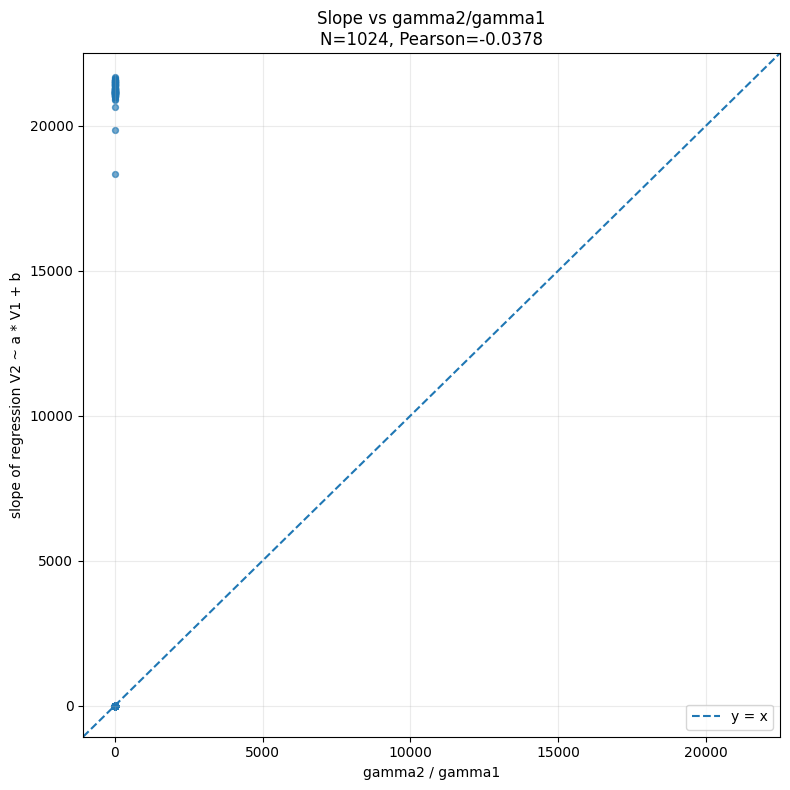

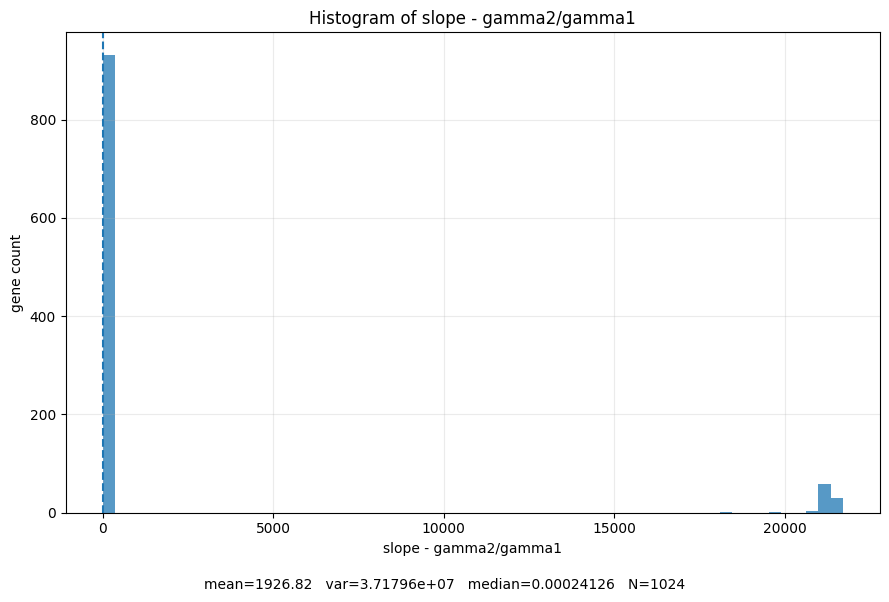

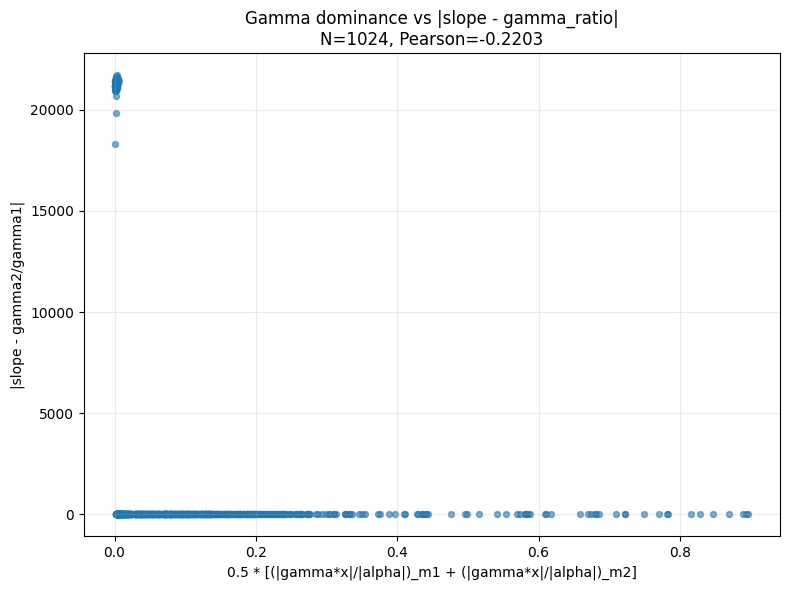

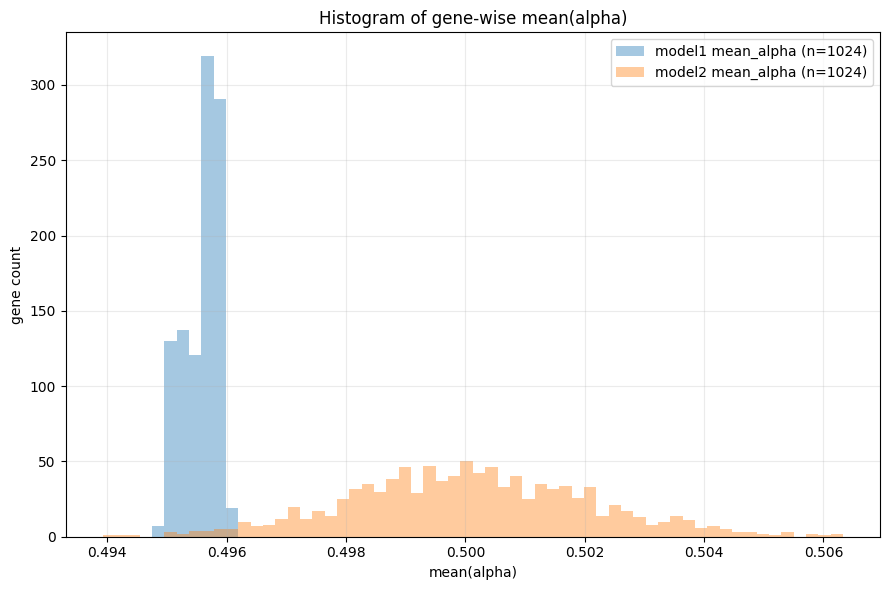

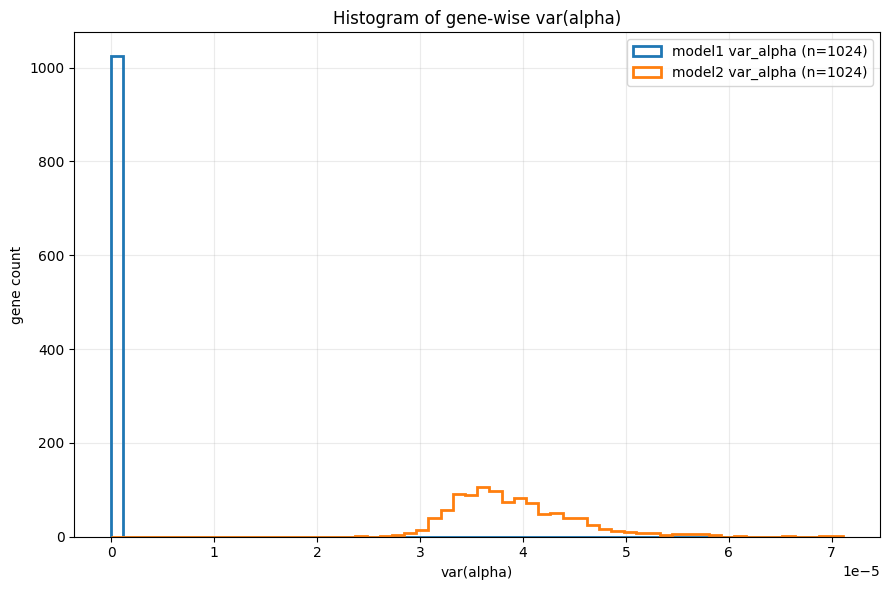

In [11]:
print("[INFO] Plotting (display only) ...")
plot_slope_vs_gamma_ratio(df)
delta_stats = plot_delta_hist(df)
plot_gamma_dominance_vs_abs_delta(df)
plot_alpha_mean_hist(diag1, diag2)
plot_alpha_var_hist(diag1, diag2)


In [ ]:



write_summary(df, delta_stats, outdir / "summary.json", args, assets)
write_readme(outdir)
write_run_record(outdir, args)

print("[DONE]")
print(csv_path)
if parquet_saved:
    print(parquet_path)
print(outdir / "summary.json")
print(outdir / "run_args.json")